# Итоговое задание дисциплины «Современные модели машинного обучения»

**Время выполнения: 3 дня**


#**Цель задания**

Валидация освоенных компетенций по темам дисциплины:
- диффузионные модели и способность применять их при решении прикладных задач;
- мультимодальные модели и использование их при решении прикладных задач;
- методы по работе с современными языковыми моделями и использование их при решении прикладных задач.


#**Условие задания**

Вам необходимо разработать модель, которая будет улучшать качество входного изображения и сделать его демонстрацию на grаdio.

План реализации:

- Вы подаете на вход любую картинку.
- С помощью модели для детекции (MDETR) находите самый большой объект и определяете его класс (3 балла).
- Используя bounding box этого объекта, маскируете этот объект на изображении.
- Далее вы должны на месте этого объекта сгенерировать объект того же типа, но более красочный. Под красочным понимается следующая модификация: "кот -> рыжий кот сидящий на скамейке, 4k, photorealistic". Эту мофидикацию вы можете реализовать вручную, добавляя прилагательные или промпты для генерации, или при помощи api-вызовов языковой модели.

 Для генерации объекта вам понадобится модель [Outpainting](https://github.com/PhilSad/stable-diffusion-outpainting) (3 балла).
- Подаете на вход модели красочный запрос и выводите финальное изображение через демонстрацию grаdio (4 балла).

#**Ожидаемый результат**

- Ipynb-ноутбук с кодом демореализации.
- Видеодемонстрация работы модели.
- 4 картинки удачных примеров.


In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [3]:
import torch
import numpy as np
from PIL import Image
from diffusers import StableDiffusionInpaintPipeline
from transformers import pipeline
import gradio as gr
import os
from pathlib import Path
from io import BytesIO
import time

print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GDRIVE_DIR = '/content/gdrive/My Drive/image_enhancement_results'
os.makedirs(GDRIVE_DIR, exist_ok=True)
print(f"Сохранено: {GDRIVE_DIR}")

GPU Available: True
GPU Device: Tesla T4
Сохранено: /content/gdrive/My Drive/image_enhancement_results


In [4]:
try:
    detector = pipeline(
        "object-detection",
        model="facebook/detr-resnet-50",
        device=0 if torch.cuda.is_available() else -1,
    )
    print("Detector загружен")
except Exception as e:
    print(f"Ошибка загрузки detector: {e}")

def detect_largest_object(image_pil):
    try:
        results = detector(image_pil)

        if not results:
            print("No objects detected")
            return None, None, None

        largest = None
        max_area = 0

        for detection in results:
            box = detection['box']
            area = (box['xmax'] - box['xmin']) * (box['ymax'] - box['ymin'])
            if area > max_area:
                max_area = area
                largest = detection

        if largest:
            label = largest['label']
            confidence = largest['score']
            bbox = (
                int(largest['box']['xmin']),
                int(largest['box']['ymin']),
                int(largest['box']['xmax']),
                int(largest['box']['ymax'])
            )
            print(f"Обнаружено: {label} (уверенность: {confidence:.2f})")
            print(f"BBox: {bbox}, Area: {max_area}")
            return label, confidence, bbox

        return None, None, None

    except Exception as e:
        print(f"Detection error: {e}")
        return None, None, None

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


Detector загружен


In [5]:
import cv2
import numpy as np

def create_mask_for_bbox(image_pil, bbox):
    """Создает маску для inpainting"""
    img_array = np.array(image_pil)
    h, w = img_array.shape[:2]

    mask = np.zeros((h, w), dtype=np.uint8)
    x1, y1, x2, y2 = map(int, bbox)
    mask[y1:y2, x1:x2] = 255

    return Image.fromarray(mask)

def add_noise_border(image_pil, mask_pil, border_size=64):
    """Добавляет шум на краях изображения"""
    img = np.array(image_pil).astype(np.float32)
    mask = np.array(mask_pil).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (border_size, border_size))
    dilated_mask = cv2.dilate(mask // 255, kernel, iterations=1)

    noise = np.random.normal(0, 10, img.shape)
    blend_area = (dilated_mask - (mask // 255)).astype(bool)
    img[blend_area] = np.clip(img[blend_area] + noise[blend_area], 0, 255)

    return Image.fromarray(np.uint8(img))

def prepare_for_inpainting(image_pil, bbox, target_size=512):
    """float bbox -> int scaling"""
    img_resized = image_pil.resize((target_size, target_size), Image.LANCZOS)

    orig_w, orig_h = image_pil.size
    scale_x = target_size / orig_w
    scale_y = target_size / orig_h

    bbox_scaled = (
        int(bbox[0] * scale_x),
        int(bbox[1] * scale_y),
        int(bbox[2] * scale_x),
        int(bbox[3] * scale_y)
    )

    if bbox_scaled[2] <= bbox_scaled[0] or bbox_scaled[3] <= bbox_scaled[1]:
        raise ValueError(f"Invalid bbox after scaling: {bbox_scaled}")

    mask = create_mask_for_bbox(img_resized, bbox_scaled)
    img_with_noise = add_noise_border(img_resized, mask, border_size=32)

    print(f"BBox scaled: {bbox_scaled}")
    return img_resized, img_with_noise, mask

print("Masking и outpainting загружены")

Masking и outpainting загружены


In [22]:
PROMPT_ENHANCEMENTS = {
    "cat": "photorealistic ginger cat sitting on wooden bench, complete body, 4 legs, head visible, detailed fur, natural pose, sharp focus, 4k",
    "dog": "a majestic golden retriever with a toy ball, 4k, photorealistic, happy expression, complete body, 4 legs, head visible, detailed fur",
    "bird": "a colorful exotic bird perched on a branch, vibrant plumage, 4k, nature photography, sharp details",
    "car": "a sleek modern sport car, sunset lighting, 4k, automotive photography, detailed",
    "house": "a beautiful modern house surrounded by greenery, golden hour lighting, 4k, architecture photography"
}

def enhance_prompt(detected_label):
    """
    Обогащает промпт на основе детектированного объекта.
    """
    label_lower = detected_label.lower().strip()

    for key, enhanced in PROMPT_ENHANCEMENTS.items():
        if key in label_lower:
            print(f"Обогащение для '{label_lower}'")
            return enhanced

    fallback = f"{detected_label}, 4k, photorealistic, detailed, vibrant colors, high quality"
    print(f"Нет промпта для '{label_lower}', используем fallback")
    return fallback

print("Обогащение промпта загружено")


Обогащение промпта загружено


In [7]:
print("Загрузка Stable Diffusion пайплайна")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    dtype=torch.float16,
    safety_checker=None,
    variant="fp16"
).to('cuda')

pipe.enable_attention_slicing("max")
pipe.enable_vae_slicing()

print(f"Pipeline device: {next(pipe.unet.parameters()).device}")
print(f"Pipeline dtype: {next(pipe.unet.parameters()).dtype}")

def inpaint_image(init_image, mask_image, prompt, num_inference_steps=25, guidance_scale=7.5):
    """
    Inpainting с torch.no_grad исправлением
    """
    print(f"Inpainting: '{prompt[:50]}...' ({num_inference_steps} шагов)")

    try:
        result = pipe(
            prompt=prompt,
            image=init_image,
            mask_image=mask_image,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale,
            negative_prompt="blurry, low quality, artifacts, ugly",
            height=512,
            width=512
        ).images[0]
        return result
    except Exception as e:
        print(f"Inpaint error: {e}")
        return pipe(
            prompt=prompt,
            image=init_image,
            mask_image=mask_image,
            num_inference_steps=15,
            guidance_scale=5.0
        ).images[0]

print("Inpainting готов")


Загрузка Stable Diffusion пайплайна


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/748 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionInpaintPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Pipeline device: cuda:0
Pipeline dtype: torch.float32
Inpainting готов


In [8]:
import gc
torch.cuda.empty_cache()

def process_image(input_image_pil):
    """
    Полный pipeline
    """
    print("PROCESSING IMAGE")

    try:
        print("\n[1/5] Определение объекта...")
        label, confidence, bbox = detect_largest_object(input_image_pil)

        if label is None:
            print("Объект не определён")
            return None, "Объект не определён", "Попробуй другое изображение"

        print(f"Найдено: {label}")

        print("\n[2/5] Подготовка inpainting...")
        img_resized, img_with_noise, mask = prepare_for_inpainting(input_image_pil, bbox)

        print("\n[3/5] Обогащение промпта...")
        enhanced_prompt = enhance_prompt(label)
        print(f"Промпт: {enhanced_prompt}")

        gc.collect()
        torch.cuda.empty_cache()

        print("\n[4/5] Запуск inpainting...")
        result_image = inpaint_image(img_with_noise, mask, enhanced_prompt)

        print("\n[5/5] Сохранение...")
        timestamp = int(time.time())
        result_path = f"{GDRIVE_DIR}/result_{timestamp}.png"
        result_image.save(result_path)
        print(f"Сохранено: {result_path}")

        return result_image, f"Обнаружено: {label} ({confidence:.2f})", enhanced_prompt

    except Exception as e:
        print(f"ERROR: {str(e)}")
        gc.collect()
        torch.cuda.empty_cache()
        return None, f"Error: {str(e)}", "Попробуй другое изображение"

print("Пайплайн готов")

Пайплайн готов


In [9]:
test_prompt = "a beautiful orange cat sitting on a wooden bench, 4k"
test_image = Image.new('RGB', (512, 512), color='gray')
test_mask = Image.new('L', (512, 512), color='white')

result = pipe(
    prompt=test_prompt,
    image=test_image,
    mask_image=test_mask,
    num_inference_steps=10,
    guidance_scale=7.5
).images[0]

result.save('/content/test_inpainting.png')
print("Тест пройден")
result.show()


  0%|          | 0/10 [00:00<?, ?it/s]

Тест пройден


In [31]:
def gradio_process(image):
    """Wrapper для Gradio"""
    if image is None:
        return None, "Не найдено изображение", ""

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    result, info, prompt = process_image(image)
    return result, info, prompt

with gr.Blocks(title="Обогащение изображения с SD") as demo:
    gr.Markdown("# Обогащение изображения с SD")
    gr.Markdown("Загрузка → Детекция → Генерация изображение")

    with gr.Row():
        with gr.Column():
            input_image = gr.Image(label="Загрузить изображение", type="pil")
            submit_btn = gr.Button("Process", variant="primary", size="lg")

        with gr.Column():
            output_image = gr.Image(label="Обогащенное изображение")

    with gr.Row():
        detection_info = gr.Textbox(label="Инфо", interactive=False)
        used_prompt = gr.Textbox(label="Промпт", interactive=False, lines=2)

    gr.Markdown("---")
    gr.Markdown("**Tips:**\n- Best with clear, well-lit images\n- Single main object works best\n- Results saved to GDrive automatically")

    submit_btn.click(
        fn=gradio_process,
        inputs=[input_image],
        outputs=[output_image, detection_info, used_prompt]
    )

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f408f9d1733c781bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Видео с работой Gradio:
https://disk.yandex.ru/i/9D26WMx0WEErIQ

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

def run(image_path: str):
    print(f"Загружаю изображение: {image_path}")
    input_image = Image.open(image_path).convert("RGB")

    result_image, info, used_prompt = process_image(input_image)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(input_image)
    plt.title("Исходное изображение")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    if result_image is not None:
        plt.imshow(result_image)
        plt.title("Обработанное изображение")
    else:
        plt.text(0.5, 0.5, info, ha="center", va="center", wrap=True)
        plt.title("Ошибка обработки")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Detection info:", info)
    print("Used prompt:", used_prompt)


Загружаю изображение: /content/gdrive/MyDrive/image_enhancement_results/01.jpg
PROCESSING IMAGE

[1/5] Определение объекта...
Обнаружено: cat (уверенность: 1.00)
BBox: (17, 74, 654, 465), Area: 249067
Найдено: cat

[2/5] Подготовка inpainting...
BBox scaled: (10, 70, 418, 445)

[3/5] Обогащение промпта...
Обогащение для 'cat'
Промпт: photorealistic ginger cat sitting on wooden bench, complete body, 4 legs, head visible, detailed fur, natural pose, sharp focus, 4k

[4/5] Запуск inpainting...
Inpainting: 'photorealistic ginger cat sitting on wooden bench,...' (25 шагов)


  0%|          | 0/25 [00:00<?, ?it/s]


[5/5] Сохранение...
Сохранено: /content/gdrive/My Drive/image_enhancement_results/result_1765101937.png


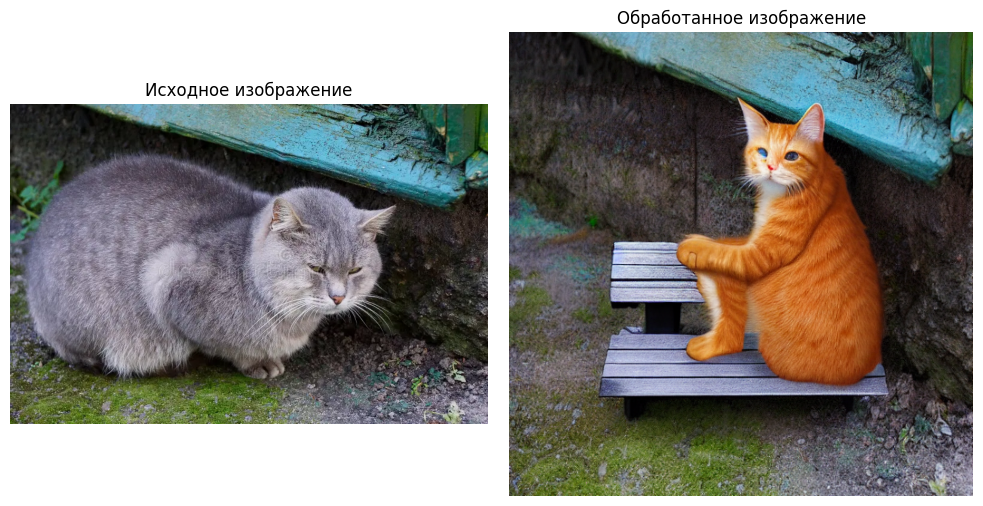

Detection info: Обнаружено: cat (1.00)
Used prompt: photorealistic ginger cat sitting on wooden bench, complete body, 4 legs, head visible, detailed fur, natural pose, sharp focus, 4k


In [15]:
run("/content/gdrive/MyDrive/image_enhancement_results/01.jpg")

:))))))))))))))))))))))))))))))))) natural pose

Загружаю изображение: /content/gdrive/MyDrive/image_enhancement_results/02.jpg
PROCESSING IMAGE

[1/5] Определение объекта...
Обнаружено: dog (уверенность: 1.00)
BBox: (367, 116, 609, 480), Area: 88088
Найдено: dog

[2/5] Подготовка inpainting...
BBox scaled: (234, 109, 389, 451)

[3/5] Обогащение промпта...
Обогащение для 'dog'
Промпт: a majestic golden retriever with a toy ball, 4k, photorealistic, happy expression, complete body, 4 legs, head visible, detailed fur

[4/5] Запуск inpainting...
Inpainting: 'a majestic golden retriever with a toy ball, 4k, p...' (25 шагов)


  0%|          | 0/25 [00:00<?, ?it/s]


[5/5] Сохранение...
Сохранено: /content/gdrive/My Drive/image_enhancement_results/result_1765102471.png


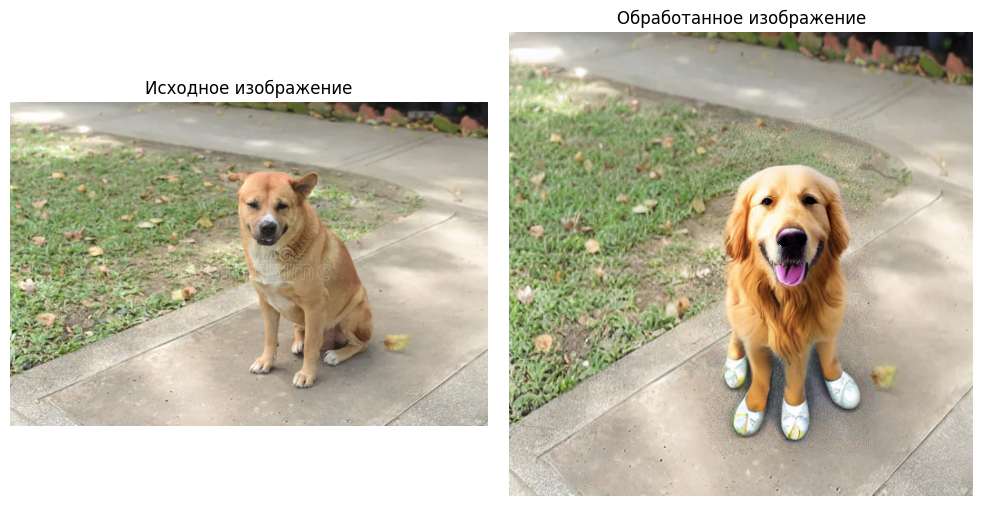

Detection info: Обнаружено: dog (1.00)
Used prompt: a majestic golden retriever with a toy ball, 4k, photorealistic, happy expression, complete body, 4 legs, head visible, detailed fur


In [20]:
run("/content/gdrive/MyDrive/image_enhancement_results/02.jpg")

классные педали, хотя просил мячик(

Загружаю изображение: /content/gdrive/MyDrive/image_enhancement_results/03.jpg
PROCESSING IMAGE

[1/5] Определение объекта...
Обнаружено: bird (уверенность: 1.00)
BBox: (270, 142, 658, 490), Area: 135024
Найдено: bird

[2/5] Подготовка inpainting...
BBox scaled: (172, 136, 421, 469)

[3/5] Обогащение промпта...
Обогащение для 'bird'
Промпт: a colorful exotic bird perched on a branch, vibrant plumage, 4k, nature photography, sharp details

[4/5] Запуск inpainting...
Inpainting: 'a colorful exotic bird perched on a branch, vibran...' (25 шагов)


  0%|          | 0/25 [00:00<?, ?it/s]


[5/5] Сохранение...
Сохранено: /content/gdrive/My Drive/image_enhancement_results/result_1765102765.png


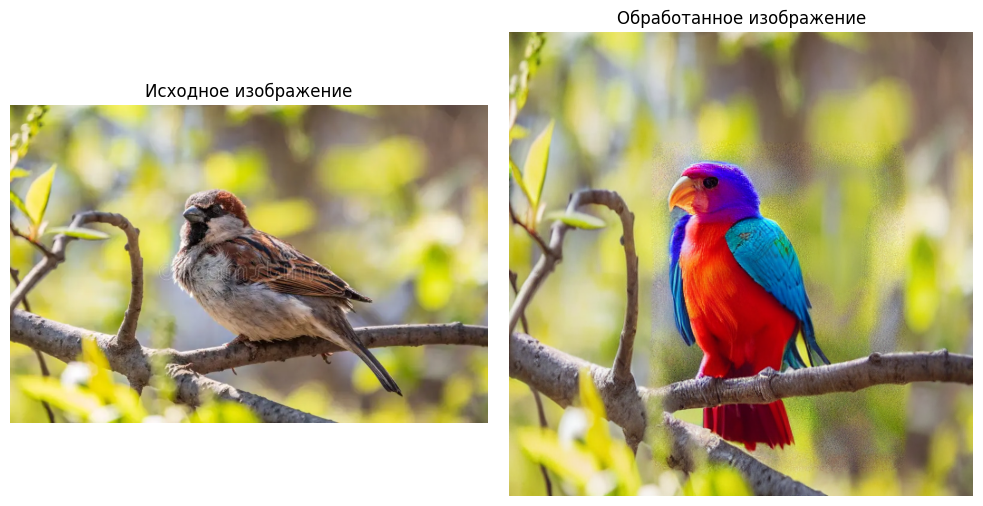

Detection info: Обнаружено: bird (1.00)
Used prompt: a colorful exotic bird perched on a branch, vibrant plumage, 4k, nature photography, sharp details


In [21]:
run("/content/gdrive/MyDrive/image_enhancement_results/03.jpg")

Загружаю изображение: /content/gdrive/MyDrive/image_enhancement_results/04.jpg
PROCESSING IMAGE

[1/5] Определение объекта...
Обнаружено: car (уверенность: 1.00)
BBox: (185, 206, 673, 420), Area: 104432
Найдено: car

[2/5] Подготовка inpainting...
BBox scaled: (118, 193, 430, 393)

[3/5] Обогащение промпта...
Обогащение для 'car'
Промпт: a sleek modern sport car, sunset lighting, 4k, automotive photography, detailed

[4/5] Запуск inpainting...
Inpainting: 'a sleek modern sport car, sunset lighting, 4k, aut...' (25 шагов)


  0%|          | 0/25 [00:00<?, ?it/s]


[5/5] Сохранение...
Сохранено: /content/gdrive/My Drive/image_enhancement_results/result_1765103375.png


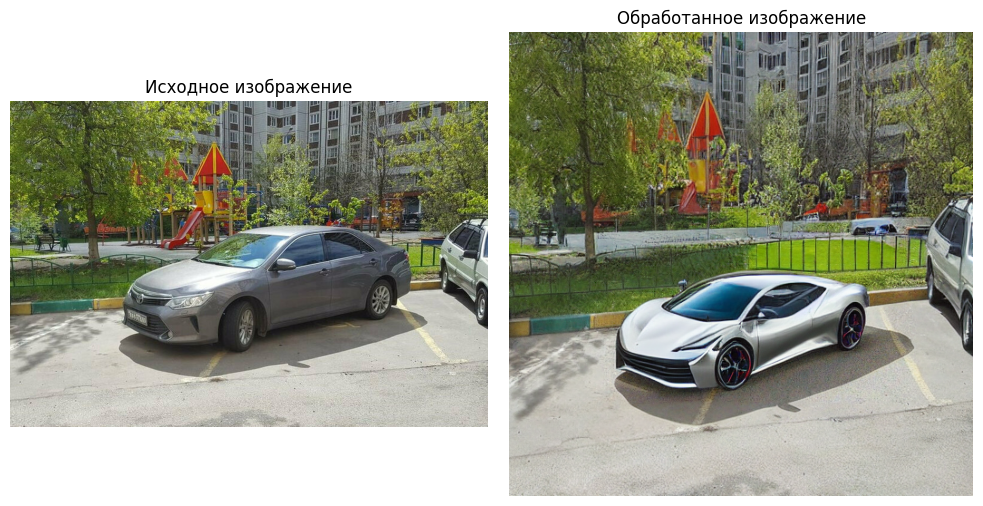

Detection info: Обнаружено: car (1.00)
Used prompt: a sleek modern sport car, sunset lighting, 4k, automotive photography, detailed


In [28]:
run("/content/gdrive/MyDrive/image_enhancement_results/04.jpg")